# Schedule Fatigue Analysis
This notebook builds a full-season NHL schedule dataset, computes fatigue features, and evaluates H1-H5 hypotheses.


## Imports and Database Connection
Load dependencies and initialize the SQLite connection used across the pipeline.


In [415]:
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

conn = sqlite3.connect('../database/nhl.db')


## Full Season Schedule Pipeline
Pull game data across the full regular season window, normalize fields, and persist the raw schedule outputs.


In [416]:
# Seed request validates the endpoint and season window assumptions
response = requests.get("https://api-web.nhle.com/v1/schedule/2025-10-07")
print(f"API status: {response.status_code}")


API status: 200


In [417]:
schedule_payload = response.json()
print('Season start:', schedule_payload['regularSeasonStartDate'])
print('Season end:', schedule_payload['regularSeasonEndDate'])


Season start: 2025-10-07
Season end: 2026-04-17


In [418]:
df_games = pd.DataFrame(response.json()['gameWeek'][0]['games'])
df_games["away_team"] = df_games["awayTeam"].apply(lambda x: x['abbrev'])
df_games["home_team"] = df_games["homeTeam"].apply(lambda x: x['abbrev'])
df_games["away_score"] = df_games["awayTeam"].apply(lambda x: x['score'])
df_games["home_score"] = df_games["homeTeam"].apply(lambda x: x['score'])
df_games["outcome_type"] = df_games["gameOutcome"].apply(lambda x: x['lastPeriodType'])

df_games = df_games[df_games['gameType'] == 2]

df_games = df_games[['id','startTimeUTC','venueTimezone','away_team','home_team','away_score','home_score','outcome_type']]

df_games['winner'] = df_games.apply(lambda x: x['away_team'] if x['away_score'] > x['home_score'] else x['home_team'], axis=1)



In [419]:
all_games = []
current_date = '2025-10-07'
season_end = '2026-04-17'

while current_date <= season_end:
    response = requests.get(f"https://api-web.nhle.com/v1/schedule/{current_date}")
    schedule_payload = response.json()
    
    for day in schedule_payload['gameWeek']:
        df_games = pd.DataFrame(day['games'])
        if df_games.empty:
            continue
        df_games["away_team"] = df_games["awayTeam"].apply(lambda x: x['abbrev'])
        df_games["home_team"] = df_games["homeTeam"].apply(lambda x: x['abbrev'])
        df_games["away_score"] = df_games["awayTeam"].apply(lambda x: x['score'])
        df_games["home_score"] = df_games["homeTeam"].apply(lambda x: x['score'])
        df_games["outcome_type"] = df_games["gameOutcome"].apply(lambda x: x['lastPeriodType'])

        df_games = df_games[df_games['gameType'] == 2]

        df_games = df_games[['id','startTimeUTC','venueTimezone','away_team','home_team','away_score','home_score','outcome_type']]

        df_games['winner'] = df_games.apply(lambda x: x['away_team'] if x['away_score'] > x['home_score'] else x['home_team'], axis=1)
        
        all_games.append(df_games)
    current_date = schedule_payload['nextStartDate']

df_schedule = pd.concat(all_games, ignore_index=True)
print(df_schedule.shape)


(1312, 9)


In [420]:
# Save to raw data
df_schedule.to_csv('../data/raw/schedule_2025_26.csv', index=False)

# Save to database
df_schedule.to_sql('schedule', conn, if_exists='replace', index=False)

print("Saved!")


Saved!


## Rest Day Calculations
Build team-level home/away schedule views, compute rest days between games, and merge rest features back to game-level records.


In [421]:
df_away = df_schedule[['id','away_team','startTimeUTC']]
df_away.rename(columns={'away_team': 'team'}, inplace=True)
df_away['location'] = 'away'

df_home = df_schedule[['id','home_team','startTimeUTC']]
df_home.rename(columns={'home_team': 'team'}, inplace=True)
df_home['location'] = 'home'

# Convert game-level schedule into team-game rows (home + away)
df_sched = pd.concat([df_away, df_home], ignore_index=True)


In [422]:
df_sched['date'] = pd.to_datetime(df_sched['startTimeUTC']).dt.date


In [423]:
df_sched = df_sched.sort_values(['team', 'date']).reset_index(drop=True)


In [424]:
df_sched['date'] = pd.to_datetime(df_sched['date'])
df_sched['rest_days'] = df_sched.groupby('team')['date'].diff().dt.days - 1



In [425]:
df_schedule['date'] = pd.to_datetime(df_schedule['startTimeUTC']).dt.date
df_schedule['date'] = pd.to_datetime(df_schedule['date'])

df_away_rest = df_schedule.merge(df_sched, left_on=['away_team', 'id'], right_on=['team', 'id'])
df_away_rest.rename(columns={'rest_days': 'away_rest'}, inplace=True)

df_home_rest = df_schedule.merge(df_sched, left_on=['home_team', 'id'], right_on=['team', 'id'])
df_home_rest.rename(columns={'rest_days': 'home_rest'}, inplace=True)

df_final = df_away_rest.merge(df_home_rest[['id','home_rest']],on='id',how='left')


In [426]:
df_final['rest_diff'] = df_final['away_rest'] - df_final['home_rest']



In [427]:
df_final.to_csv('../data/raw/schedule_with_rest_nhl_2025_26.csv', index=False)

# Save to database
df_final.to_sql('schedule', conn, if_exists='replace', index=False)

print("Saved!")


Saved!


## H1: Back-to-Back Win Rates
Test whether away and home teams perform differently in back-to-back contexts relative to baseline win rates.


In [428]:
df_away_b2b = df_final[df_final['away_rest'] == 0]

away_b2b_win_rate = (df_away_b2b['winner'] == df_away_b2b['away_team']).mean()

print(f"Away team win rate on back-to-backs: {away_b2b_win_rate:.1%}")
print(f"Sample size: {len(df_away_b2b)} games")


Away team win rate on back-to-backs: 42.0%
Sample size: 350 games


In [429]:
away_overall_win_rate = (df_final['winner'] == df_final['away_team']).mean()

print(f"Away team win rate overall: {away_overall_win_rate:.1%}")
print(f"Sample size: {len(df_final)} games")


Away team win rate overall: 47.8%
Sample size: 1312 games


**Context note:** The 2025-26 NHL season included an Olympic break, 
which compressed the schedule in surrounding weeks. This may inflate 
the frequency of back-to-back games compared to a typical season and 
should be considered when interpreting fatigue effects.

In [430]:
df_home_b2b = df_final[df_final['home_rest'] == 0]

home_b2b_win_rate = (df_home_b2b['winner'] == df_home_b2b['home_team']).mean()

print(f"Home team win rate on back-to-backs: {home_b2b_win_rate:.1%}")
print(f"Sample size: {len(df_home_b2b)} games")


Home team win rate on back-to-backs: 54.5%
Sample size: 253 games


In [431]:
home_overall_win_rate = (df_final['winner'] == df_final['home_team']).mean()

print(f"Home team win rate overall: {home_overall_win_rate:.1%}")
print(f"Sample size: {len(df_final)} games")


Home team win rate overall: 52.2%
Sample size: 1312 games


In [432]:
print("=== H1: Back-to-Back Win Rates ===")
print(f"Overall away win rate:        {away_overall_win_rate:.1%} (n={len(df_final)})")
print(f"Away win rate on B2B:         {away_b2b_win_rate:.1%} (n={len(df_away_b2b)})")
print(f"Home win rate on B2B:         {home_b2b_win_rate:.1%} (n={len(df_home_b2b)})")
print(f"Away B2B impact:              {away_b2b_win_rate - away_overall_win_rate:.1%}")


=== H1: Back-to-Back Win Rates ===
Overall away win rate:        47.8% (n=1312)
Away win rate on B2B:         42.0% (n=350)
Home win rate on B2B:         54.5% (n=253)
Away B2B impact:              -5.8%


**H3 Enrichment — Back-to-Back Types:**
Not all back-to-backs are equal. A home→away back-to-back involves 
playing then immediately traveling, compounding fatigue beyond rest 
days alone. We can categorize B2B games into four types using the 
`location` field in `df_sched`:

- **Home → Away** (hardest — play then travel overnight)
- **Away → Home** (travel then play in front of home crowd)  
- **Away → Away** (consecutive road games, continuous travel)
- **Home → Home** (easiest — no travel component)

The Penguins/Capitals example in March 2026 (PIT then WSH) is a 
classic Home → Away back-to-back. Incorporate into H3 timezone 
travel analysis.

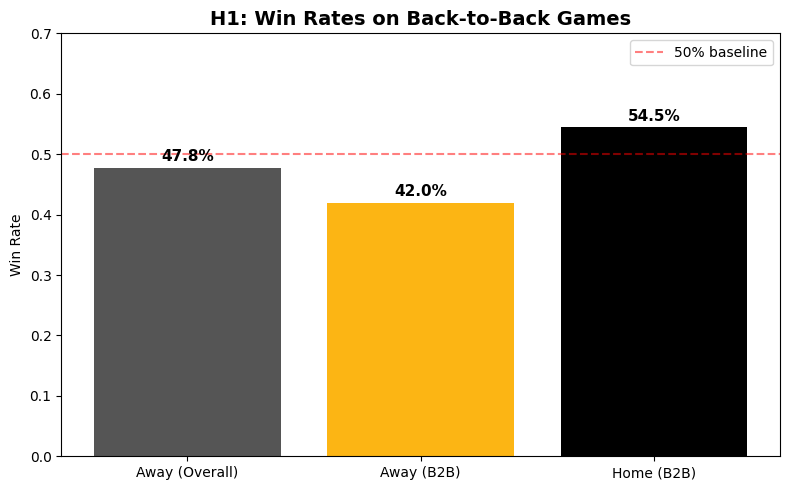

In [433]:
labels = ['Away (Overall)', 'Away (B2B)', 'Home (B2B)']
values = [away_overall_win_rate, away_b2b_win_rate, home_b2b_win_rate]
colors = ['#555555', '#FCB514', '#000000']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% baseline')
ax.set_ylabel('Win Rate')
ax.set_title('H1: Win Rates on Back-to-Back Games', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.7)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

ax.legend()
plt.tight_layout()
plt.savefig('../visuals/08_h1_b2b_win_rates.png', dpi=150, bbox_inches='tight')
plt.show()


## H2: Rest Differential Effects
Measure how away-team win probability changes when the away side is more rested, equally rested, or less rested.


In [434]:
# away team had more rest
df_away_rest = df_final[df_final['rest_diff'] > 0]

away_rest_win_rate = (df_away_rest['winner'] == df_away_rest['away_team']).mean()

print(f"Away team win rate when more rested: {away_rest_win_rate:.1%}")
print(f"Sample size: {len(df_away_rest)} games")

# teams had equal rest
away_equal_rest = df_final[df_final['rest_diff'] == 0]

away_equal_win_rate = (away_equal_rest['winner'] == away_equal_rest['away_team']).mean()

print(f"Away team win rate on equal rest: {away_equal_win_rate:.1%}")
print(f"Sample size: {len(away_equal_rest)} games")

# away team had more rest
df_home_rest = df_final[df_final['rest_diff'] < 0]

away_tired_win_rate = (df_home_rest['winner'] == df_home_rest['away_team']).mean()

print(f"Away team win rate on less rest: {away_tired_win_rate:.1%}")
print(f"Sample size: {len(df_home_rest)} games")


Away team win rate when more rested: 51.1%
Sample size: 274 games
Away team win rate on equal rest: 50.2%
Sample size: 624 games
Away team win rate on less rest: 41.4%
Sample size: 394 games


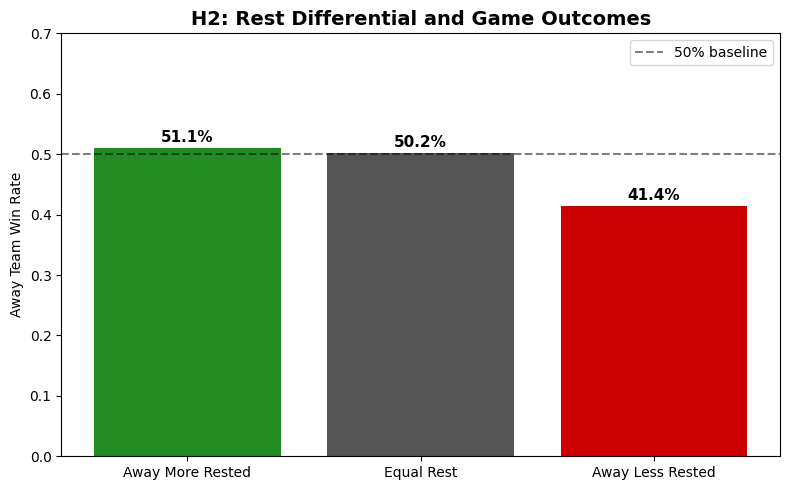

In [435]:
labels = ['Away More Rested', 'Equal Rest', 'Away Less Rested']
values = [away_rest_win_rate, away_equal_win_rate, away_tired_win_rate]
colors = ['#228B22', '#555555', '#CC0000']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors)
ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='50% baseline')
ax.set_ylabel('Away Team Win Rate')
ax.set_title('H2: Rest Differential and Game Outcomes', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.7)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

ax.legend()
plt.tight_layout()
plt.savefig('../visuals/09_h2_rest_differential.png', dpi=150, bbox_inches='tight')
plt.show()


## H3: Timezone Travel and Fatigue
Estimate directional timezone-shift effects and contextualize travel findings with known confounding factors.


In [436]:
timezone_offsets = {
    'America/New_York': -5,
    'America/Toronto': -5,
    'America/Detroit': -5,
    'America/Chicago': -6,
    'US/Central': -6,
    'US/Eastern': -5,
    'America/Denver': -7,
    'US/Mountain': -7,
    'America/Los_Angeles': -8,
    'US/Pacific': -8,
    'America/Vancouver': -8,
    'America/Edmonton': -7,
    'America/Winnipeg': -6,
    'America/Phoenix': -7,
}

df_final['venue_utc_offset'] = df_final['venueTimezone'].map(timezone_offsets)



In [437]:
timezone_offsets['America/Montreal'] = -5

# Remap
df_final['venue_utc_offset'] = df_final['venueTimezone'].map(timezone_offsets)

# Exclude Stockholm games
df_final = df_final[df_final['venue_utc_offset'].notna()]


In [438]:
df_sched = df_sched.merge(df_final[['id', 'venue_utc_offset']], on='id', how='left')


In [439]:
df_sched['tz_shift'] = df_sched.groupby('team')['venue_utc_offset'].diff()


In [440]:
df_sched_away = df_sched[df_sched['location'] == 'away'][['id', 'tz_shift']]
df_final = df_final.merge(df_sched_away, on='id', how='left')


In [441]:
# no time zone shift 
df_no_shift = df_final[df_final['tz_shift'] == 0]

no_shift_win_rate = (df_no_shift['winner'] == df_no_shift['away_team']).mean()

print(f"Win rate with no time zone shift: {no_shift_win_rate:.1%}")
print(f"Sample size: {len(df_no_shift)} games")

# positive small time zone shift (1-2 hours) - eastward
df_small_shift = df_final[(df_final['tz_shift'] == 1) | (df_final['tz_shift'] == 2)]

small_shift_win_rate = (df_small_shift['winner'] == df_small_shift['away_team']).mean()

print(f"Win rate with 1-2 hour time zone shift (positive - eastward): {small_shift_win_rate:.1%}")
print(f"Sample size: {len(df_small_shift)} games")

#negative small time zone shift (1-2 hours) - westward
df_small_neg_shift = df_final[(df_final['tz_shift'] == -1) | (df_final['tz_shift'] == -2)]

small_neg_win_rate = (df_small_neg_shift['winner'] == df_small_neg_shift['away_team']).mean()

print(f"Win rate with 1-2 hour time zone shift (negative - westward): {small_neg_win_rate:.1%}")
print(f"Sample size: {len(df_small_neg_shift)} games")

# large time zone shift (3+ hours)
df_large_shift = df_final[df_final['tz_shift'] >= 3]

large_shift_win_rate = (df_large_shift['winner'] == df_large_shift['away_team']).mean()

print(f"Win rate with 3+ hours time zone shift: {large_shift_win_rate:.1%}")
print(f"Sample size: {len(df_large_shift)} games")


Win rate with no time zone shift: 45.7%
Sample size: 814 games
Win rate with 1-2 hour time zone shift (positive - eastward): 50.0%
Sample size: 224 games
Win rate with 1-2 hour time zone shift (negative - westward): 55.1%
Sample size: 207 games
Win rate with 3+ hours time zone shift: 40.0%
Sample size: 20 games


**H3 Caveat: Confounding Variables in Westward Travel Analysis** The analysis above shows that westward travel correlates with better performance compared to eastward travel or large timezone shifts (3+ hours). The reality of the 2025-26 season is that western conference teams had fewer cumulative points than those in the eastern conference - one explanation for the improved westward travel performance is opponent quality rather than travel direction itself. 

This confounding variable will be addressed in H5, where logistic regression allows us to control for team quality alongside rest and travel variables simultaneously.

## H4: Team Resilience to Fatigue
Compare team-level back-to-back outcomes against overall quality to identify over- and under-performance under fatigue.


In [442]:
df_away_b2b = df_final[df_final['away_rest'] == 0].copy()
df_away_b2b['away_won'] = (df_away_b2b['winner'] == df_away_b2b['away_team'])

away_b2b_by_team = df_away_b2b.groupby('away_team')['away_won'].mean()
#away_b2b_by_team.head()

df_home_b2b = df_final[df_final['home_rest'] == 0].copy()
df_home_b2b['home_won'] = (df_home_b2b['winner'] == df_home_b2b['home_team'])

home_b2b_by_team = df_home_b2b.groupby('home_team')['home_won'].mean()


In [443]:
df_away_b2b_rates = away_b2b_by_team.reset_index()
df_away_b2b_rates.columns = ['team', 'away_b2b_win_rate']

df_home_b2b_rates = home_b2b_by_team.reset_index()
df_home_b2b_rates.columns = ['team', 'home_b2b_win_rate']

df_merge_b2b = df_away_b2b_rates.merge(df_home_b2b_rates, on='team', how='left')


In [444]:
df_merge_b2b['overall_b2b_win_rate'] = (df_merge_b2b['away_b2b_win_rate'] + df_merge_b2b['home_b2b_win_rate']) / 2


In [445]:
conn = sqlite3.connect('../database/nhl.db')
df_standings = pd.read_sql_query("SELECT team_abbrev, winPctg FROM standings", conn)


In [446]:
df_standings = df_standings.merge(df_merge_b2b,left_on='team_abbrev',right_on='team')


In [447]:
df_standings['fatigue_impact'] = df_standings['overall_b2b_win_rate'] - df_standings['winPctg']

df_standings.sort_values('fatigue_impact')


,team_abbrev,winPctg,team,away_b2b_win_rate,home_b2b_win_rate,overall_b2b_win_rate,fatigue_impact
24,FLA,0.487805,FLA,0.300000,0.333333,0.316667,-0.171138
16,CBJ,0.487805,CBJ,0.400000,0.333333,0.366667,-0.121138
9,PIT,0.500000,PIT,0.307692,0.466667,0.387179,-0.112821
14,UTA,0.524390,UTA,0.500000,0.333333,0.416667,-0.107723
1,CAR,0.646341,CAR,0.416667,0.666667,0.541667,-0.104674
17,ANA,0.524390,ANA,0.222222,0.625000,0.423611,-0.100779
15,DET,0.500000,DET,0.375000,0.454545,0.414773,-0.085227
29,NYR,0.414634,NYR,0.333333,0.333333,0.333333,-0.081301
6,MIN,0.560976,MIN,0.384615,0.583333,0.483974,-0.077002
10,PHI,0.524390,PHI,0.583333,0.333333,0.458333,-0.066057


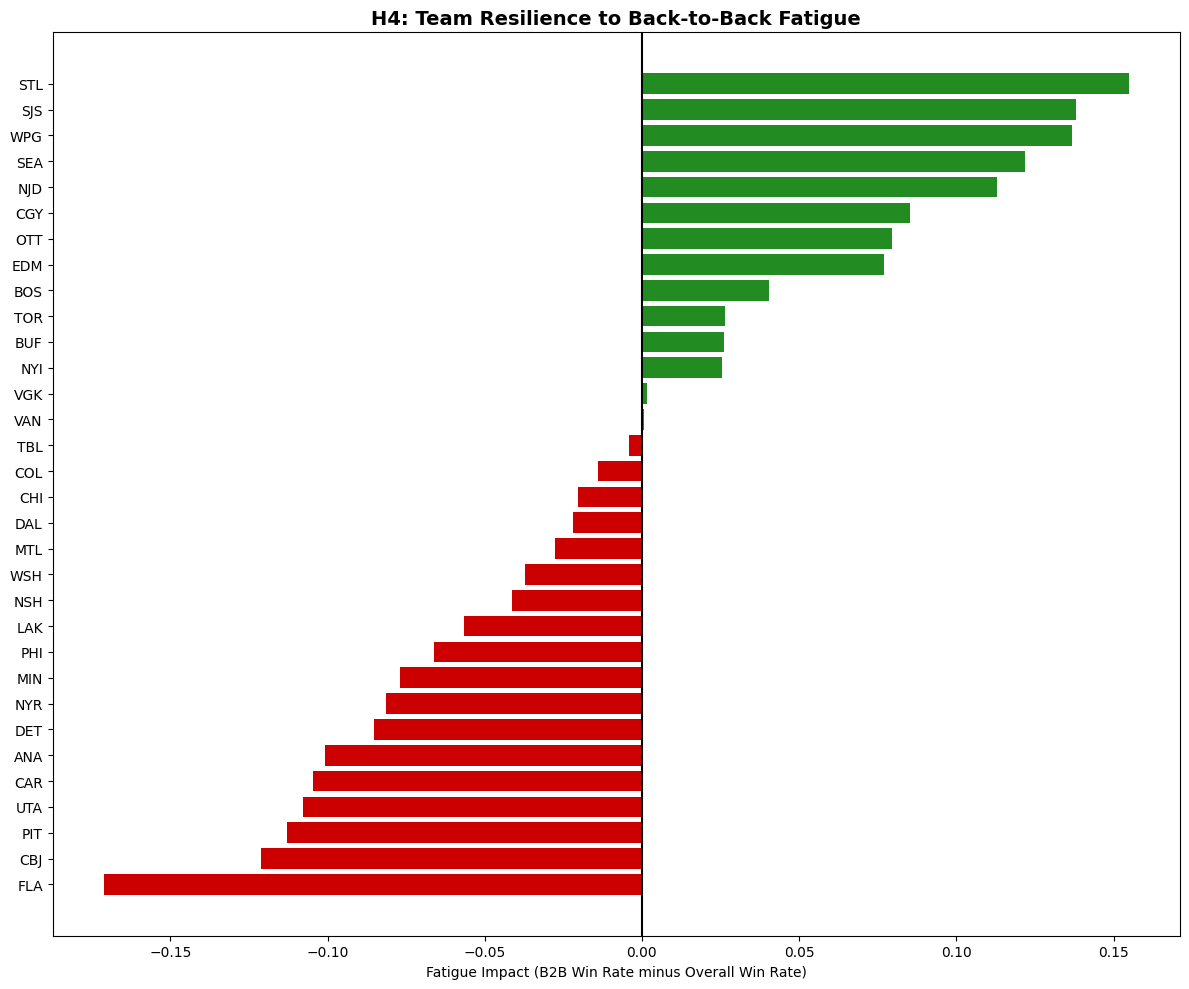

In [448]:
df_resilience = df_standings.sort_values('fatigue_impact', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))

colors = ['#CC0000' if x < 0 else '#228B22' for x in df_resilience['fatigue_impact']]
ax.barh(df_resilience['team_abbrev'], df_resilience['fatigue_impact'], color=colors)
ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_xlabel('Fatigue Impact (B2B Win Rate minus Overall Win Rate)')
ax.set_title('H4: Team Resilience to Back-to-Back Fatigue', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/10_h4_team_resilience.png', dpi=150, bbox_inches='tight')
plt.show()


**H4 Enrichment — Team Age Analysis:**
Roster age may explain some of the variance in fatigue resilience scores. 
Older rosters (like Pittsburgh) may be more vulnerable to back-to-back 
fatigue than younger ones. Team age can be derived by pulling `birthDate` 
from the roster endpoint for all 32 teams and correlating average age with 
fatigue impact score. Flagged for future analysis.

## H5: Logistic Regression Upset Model
Model upset probability using rest and travel predictors while accounting for class imbalance.


In [449]:
df_final = df_final.merge(df_standings[['team_abbrev','winPctg']],left_on='away_team',right_on='team_abbrev')
df_final.rename(columns={'winPctg': 'away_winPctg'}, inplace=True)

df_final = df_final.merge(df_standings[['team_abbrev','winPctg']],left_on='home_team',right_on='team_abbrev')
df_final.rename(columns={'winPctg': 'home_winPctg'}, inplace=True)


In [450]:
df_final = df_final.drop(columns=['team_abbrev_x', 'team_abbrev_y'])


In [451]:
# Label an upset when the weaker away team wins on the road
df_final['upsets'] = df_final.apply(lambda x: 1 if (x['away_winPctg'] < x['home_winPctg']) & (x['away_team'] == x['winner']) else 0, axis=1)


In [452]:
print(f"Total upsets: {df_final['upsets'].sum()}")
print(f"Upset rate: {df_final['upsets'].mean():.1%}")


Total upsets: 235
Upset rate: 17.9%


In [453]:
feature_cols = ['rest_diff', 'tz_shift', 'away_rest', 'home_rest']


In [454]:
df_model = df_final[feature_cols + ['upsets']].dropna()


In [455]:
# Define feature matrix and target label
X_features = df_model[['rest_diff', 'tz_shift', 'away_rest', 'home_rest']]
y_upset = df_model['upsets']

# Keep a holdout set to evaluate generalization
X_train, X_test, y_train, y_test = train_test_split(X_features, y_upset, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Training set: (1032, 4)
Test set: (258, 4)


In [456]:
# Train the model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Evaluate on test set
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.80      1.00      0.89       207
           1       0.00      0.00      0.00        51

    accuracy                           0.80       258
   macro avg       0.40      0.50      0.45       258
weighted avg       0.64      0.80      0.71       258



/Users/amyeast/projects/nhl-analytics-portfolio/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/amyeast/projects/nhl-analytics-portfolio/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/amyeast/projects/nhl-analytics-portfolio/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [457]:
model_balanced = LogisticRegression(random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)
print(classification_report(y_test, y_pred_balanced))


              precision    recall  f1-score   support

           0       0.79      0.64      0.71       207
           1       0.18      0.31      0.23        51

    accuracy                           0.58       258
   macro avg       0.48      0.48      0.47       258
weighted avg       0.67      0.58      0.61       258



In [458]:
df_predictions = X_test.copy()
df_predictions['upset_probability'] = y_proba
df_predictions['actual_upset'] = y_test.values
df_predictions = df_predictions.sort_values('upset_probability', ascending=False)


In [459]:
print(f"Top 20 highest upset probability games:")
print(f"Actual upsets in top 20: {df_predictions.head(20)['actual_upset'].sum()}")
print(f"Upset rate in top 20: {df_predictions.head(20)['actual_upset'].mean():.1%}")
print(f"Vs overall upset rate: {df_final['upsets'].mean():.1%}")


Top 20 highest upset probability games:
Actual upsets in top 20: 3
Upset rate in top 20: 15.0%
Vs overall upset rate: 17.9%


**H5 Methodological Note — Missing Data:**
Approximately 20 rows (~1.5% of games) were dropped due to missing rest 
and travel data, primarily from opening night and post-Olympic break games 
where no previous game existed to calculate rest days from. An alternative 
approach would be median imputation, but given the negligible data loss, 
dropping is the more defensible choice.

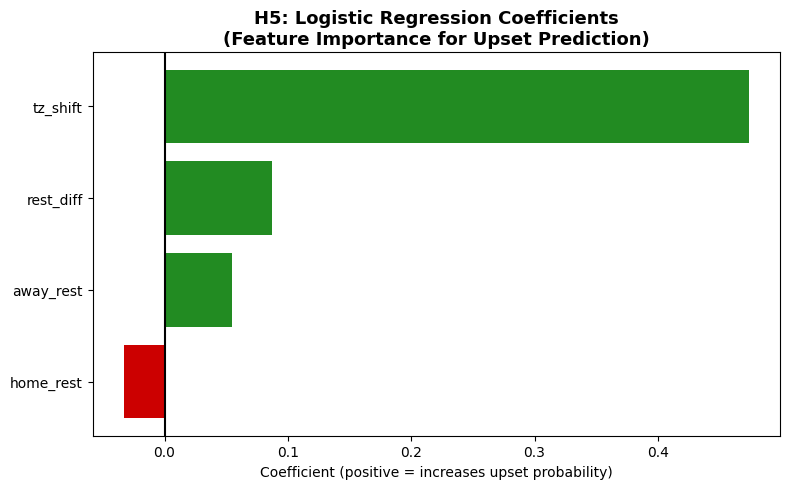

In [460]:
coef_df = pd.DataFrame({
    'feature': ['rest_diff', 'tz_shift', 'away_rest', 'home_rest'],
    'coefficient': model_balanced.coef_[0]
}).sort_values('coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#CC0000' if x < 0 else '#228B22' for x in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_title('H5: Logistic Regression Coefficients\n(Feature Importance for Upset Prediction)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient (positive = increases upset probability)')
plt.tight_layout()
plt.savefig('../visuals/11_h5_model_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


### H5 Interpretation: Upset Probability Model

Logistic regression predicts the probability of a binary outcome — in this 
case, whether an upset occurs or not. Upsets are defined as the weaker away 
team (by points percentage) winning on the road, with the variables of rest 
differential, timezone shift, away team rest, and home team rest.

Upsets in the 2025-26 NHL season were rare (18% of all games), and the first 
iteration of the logistic regression didn't predict any upsets at all because 
the probability was so low. To fix this, we added class weights to the model 
to penalize missing an upset more heavily, which then started predicting upsets, 
catching 31% of actual upsets, but when it predicted an upset it was only 
correct 18% of the time.

Despite its limitations, the model's coefficients reveal meaningful signal about 
which variables matter most. Timezone shift is the strongest predictor by a 
significant margin, followed by rest differential and then away rest. Home rest 
was negative, indicating that more home rest decreases upset probability. One 
caveat to the timezone shift coefficient (identified in H3) is that in 2025-26 
the western conference teams had fewer cumulative points than eastern conference 
teams. For eastern conference teams going west (or vice-versa), road trips could 
be influenced by opponent quality and not truly indicative of timezone shift 
helping or hindering performance.

Rest and travel variables alone are insufficient to predict upsets reliably 
(31% recall). Team quality (points percentage, roster age, and back-to-back type) 
would directly address the confounding variables identified in H3, while betting 
odds would provide a market-based baseline that already accounts for many factors 
our model currently lacks. Both will be explored in future analysis.